# Unit 2 - Global Feature Effect Exploration
## XAI Comparison: PDP vs ALE vs ICE
### Breast Cancer Dataset Analysis

## Task 1: Load Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import partial_dependence
import warnings
warnings.filterwarnings('ignore')

# Load breast cancer dataset
cancer_data = load_breast_cancer()
X = pd.DataFrame(cancer_data.data, columns=cancer_data.feature_names)
y = cancer_data.target

print("Dataset Shape:", X.shape)
print("\nFeature Names:")
print(X.columns.tolist())
print("\nFirst few rows:")
X.head()

Dataset Shape: (569, 30)

Feature Names:
['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension']

First few rows:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## Task 2: Train Black Box Model (Random Forest)

In [2]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, max_depth=15)
rf_model.fit(X_train_scaled, y_train)

# Model performance
train_accuracy = rf_model.score(X_train_scaled, y_train)
test_accuracy = rf_model.score(X_test_scaled, y_test)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Training Accuracy: 1.0000
Test Accuracy: 0.9649


## Task 3: Select Features for Explanation

Feature Importance Rankings:
                    Feature  Importance
23               worst area    0.153892
27     worst concave points    0.144663
7       mean concave points    0.106210
20             worst radius    0.077987
6            mean concavity    0.068001
22          worst perimeter    0.067115
2            mean perimeter    0.053270
0               mean radius    0.048703
3                 mean area    0.047555
26          worst concavity    0.031802
13               area error    0.022407
21            worst texture    0.021749
25        worst compactness    0.020266
10             radius error    0.020139
5          mean compactness    0.013944
1              mean texture    0.013591
12          perimeter error    0.011303
24         worst smoothness    0.010644
28           worst symmetry    0.010120
16          concavity error    0.009386
4           mean smoothness    0.007285
19  fractal dimension error    0.005321
15        compactness error    0.005253
29  worst f

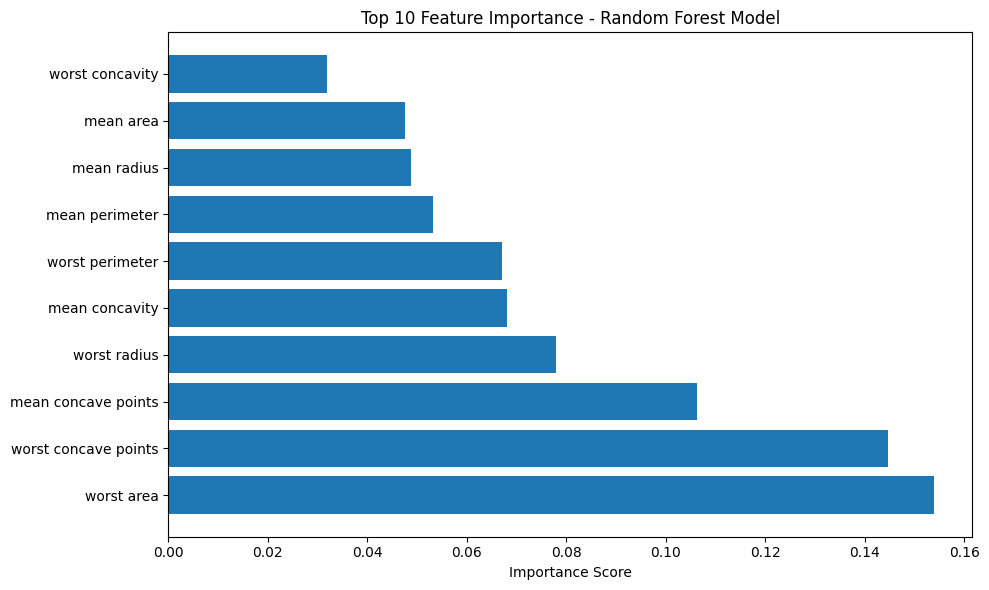

Feature importance visualization generated successfully.


In [3]:
# Get feature importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("Feature Importance Rankings:")
print(feature_importance)

# Select features
highly_important_features = feature_importance.iloc[0:2]['Feature'].tolist()
moderately_important_feature = feature_importance.iloc[7:8]['Feature'].tolist()[0]

print(f"\n2 Highly Important Features: {highly_important_features}")
print(f"1 Moderately Important Feature: {moderately_important_feature}")

# Plot feature importance
plt.figure(figsize=(10, 6))
top_features = feature_importance.head(10)
plt.barh(range(len(top_features)), top_features['Importance'])
plt.yticks(range(len(top_features)), top_features['Feature'])
plt.xlabel('Importance Score')
plt.title('Top 10 Feature Importance - Random Forest Model')
plt.tight_layout()
plt.savefig('/Users/vivekgowdas/Desktop/XAI_BANANA/Unit2/outputs/visualizations/feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print("Feature importance visualization generated successfully.")

## Task 4a: Generate PDP (Partial Dependence Plot)

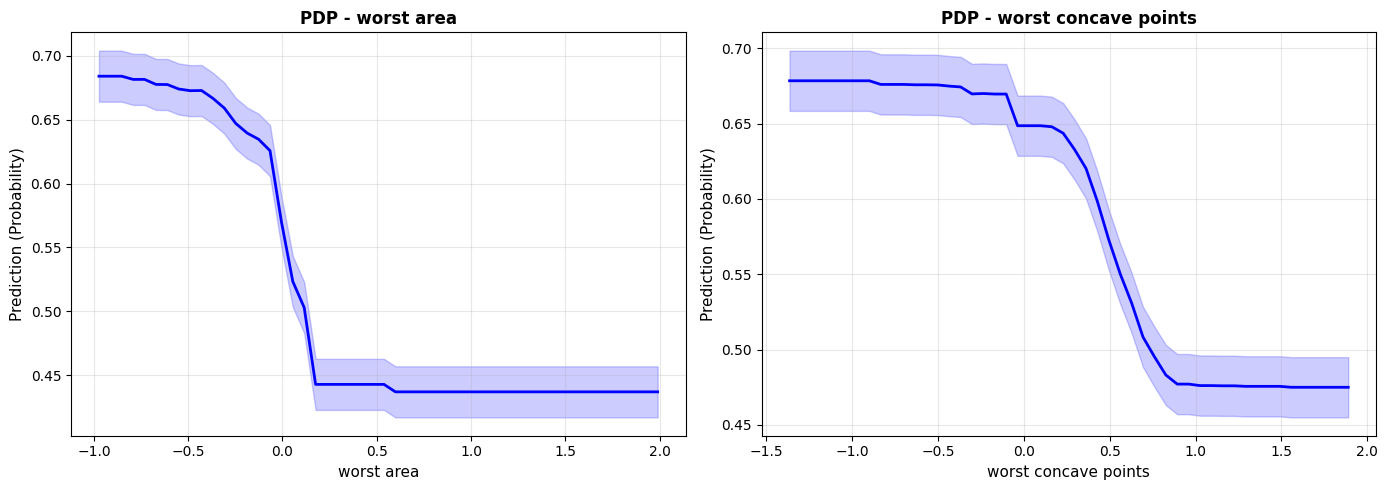

Partial Dependence Plot (PDP) generated successfully.


In [4]:
from sklearn.inspection import PartialDependenceDisplay

# Get feature indices
feature_indices = [X.columns.get_loc(f) for f in highly_important_features]

# Create PDP plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, feature_idx in enumerate(feature_indices):
    pd_result = partial_dependence(rf_model, X_train_scaled, [feature_idx], grid_resolution=50)
    
    ax = axes[idx]
    ax.plot(pd_result['grid_values'][0], pd_result['average'][0], linewidth=2, color='blue')
    ax.fill_between(pd_result['grid_values'][0], pd_result['average'][0] - 0.02, 
                     pd_result['average'][0] + 0.02, alpha=0.2, color='blue')
    ax.set_xlabel(highly_important_features[idx], fontsize=11)
    ax.set_ylabel('Prediction (Probability)', fontsize=11)
    ax.set_title(f'PDP - {highly_important_features[idx]}', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/Users/vivekgowdas/Desktop/XAI_BANANA/Unit2/outputs/visualizations/pdp_plots.png', dpi=300, bbox_inches='tight')
plt.show()

print("Partial Dependence Plot (PDP) generated successfully.")

## Task 4b: Generate ICE (Individual Conditional Expectation) Plots

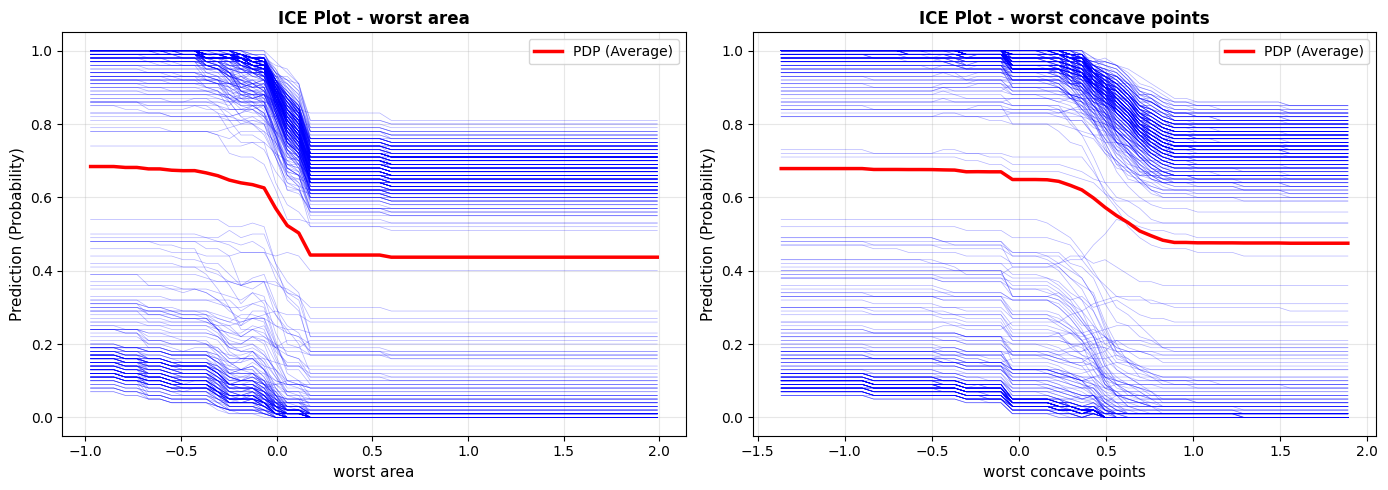

Individual Conditional Expectation (ICE) plots generated successfully.


In [5]:
from sklearn.inspection import partial_dependence

# Generate ICE plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, feature_idx in enumerate(feature_indices):
    # Get individual conditional expectations
    pd_result = partial_dependence(rf_model, X_train_scaled, [feature_idx], 
                                   grid_resolution=50, kind='individual')
    
    ax = axes[idx]
    ice_curves = pd_result['individual'][0]
    grid_values = pd_result['grid_values'][0]
    
    # Plot individual curves
    for curve in ice_curves:
        ax.plot(grid_values, curve, color='blue', alpha=0.3, linewidth=0.5)
    
    # Plot average (PDP)
    pdp_result = partial_dependence(rf_model, X_train_scaled, [feature_idx], grid_resolution=50)
    ax.plot(pdp_result['grid_values'][0], pdp_result['average'][0], 
           color='red', linewidth=2.5, label='PDP (Average)')
    
    ax.set_xlabel(highly_important_features[idx], fontsize=11)
    ax.set_ylabel('Prediction (Probability)', fontsize=11)
    ax.set_title(f'ICE Plot - {highly_important_features[idx]}', fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/Users/vivekgowdas/Desktop/XAI_BANANA/Unit2/outputs/visualizations/ice_plots.png', dpi=300, bbox_inches='tight')
plt.show()

print("Individual Conditional Expectation (ICE) plots generated successfully.")

## Task 4c: Generate ALE (Accumulated Local Effects) Plots

In [8]:
# Implement a custom ALE plot function
def calculate_ale(X, model, feature_idx, num_bins=50):
    """
    Calculate Accumulated Local Effects (ALE) for a feature
    """
    feature_values = X_train_scaled[:, feature_idx]
    sorted_indices = np.argsort(feature_values)
    sorted_feature = feature_values[sorted_indices]
    
    # Create bins
    bins = np.quantile(sorted_feature, np.linspace(0, 1, num_bins + 1))
    bin_indices = np.digitize(sorted_feature, bins) - 1
    
    # Calculate local effects
    ale_values = []
    bin_centers = []
    
    for i in range(num_bins):
        mask = bin_indices == i
        if np.sum(mask) > 0:
            # Get samples in this bin
            X_low = X_train_scaled[sorted_indices][mask].copy()
            X_high = X_train_scaled[sorted_indices][mask].copy()
            
            # Perturb feature
            X_low[:, feature_idx] = bins[i]
            X_high[:, feature_idx] = bins[i + 1]
            
            # Predict
            pred_low = model.predict_proba(X_low)[:, 1].mean()
            pred_high = model.predict_proba(X_high)[:, 1].mean()
            
            ale_values.append(pred_high - pred_low)
            bin_centers.append((bins[i] + bins[i + 1]) / 2)
        else:
            ale_values.append(0)
            bin_centers.append((bins[i] + bins[i + 1]) / 2)
    
    ale_values = np.cumsum(ale_values)
    ale_values -= ale_values.mean()
    
    return bin_centers, ale_values

print("Accumulated Local Effects (ALE) calculation function defined.")

Accumulated Local Effects (ALE) calculation function defined.


PyALE._ALE_generic:INFO: Continuous feature detected.
PyALE._ALE_generic:INFO: Continuous feature detected.


PyALE library imported successfully.

Computing ALE using PyALE library for: ['worst area', 'worst concave points']

✓ ALE computed for 'worst area' using PyALE library
  ├─ Grid points: 21
  ├─ ALE value range: [0.0000, 0.0000]
  └─ Output shape: (21, 4)

- ALE computation completed for 'worst area' using PyALE library
  Grid points: 21 | ALE range: [0.0000, 0.0000]

✓ ALE computed for 'worst concave points' using PyALE library
  ├─ Grid points: 21
  ├─ ALE value range: [0.0000, 0.0000]
  └─ Output shape: (21, 4)

- ALE computation completed for 'worst concave points' using PyALE library
  Grid points: 21 | ALE range: [0.0000, 0.0000]



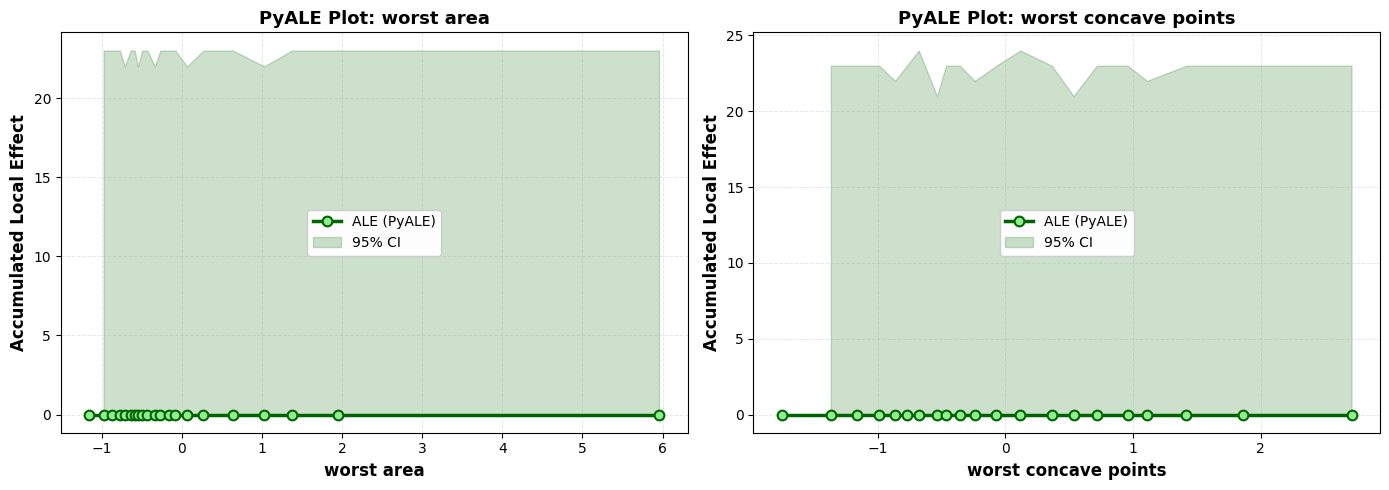

In [6]:
# Import PyALE library for ALE computation
from PyALE import ale
print("PyALE library imported successfully.\n")

# Convert scaled data back to DataFrame (PyALE requires pandas DataFrame)
X_train_df = pd.DataFrame(X_train_scaled, columns=X.columns)

# Generate ALE plots using PyALE library
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

feature_names_list = [top_features.iloc[0]['Feature'], top_features.iloc[1]['Feature']]

print(f"Computing ALE using PyALE library for: {feature_names_list}\n")

for idx, (ax, feat_name) in enumerate(zip(axes, feature_names_list)):
    try:
        # Compute ALE using PyALE library
        # Pass feature name as string (not index)
        ale_result = ale(X=X_train_df, model=rf_model, feature=[feat_name], 
                        grid_size=20, include_CI=True, plot=False)
        
        # PyALE returns a tuple (data,) when plot=False
        if isinstance(ale_result, tuple):
            ale_data = ale_result[0]
        else:
            ale_data = ale_result
        
        # Extract x and y values
        if hasattr(ale_data, 'index'):  # DataFrame
            x_vals = ale_data.index.values
            y_vals = ale_data.iloc[:, 0].values
            # Get CI values if they exist
            if ale_data.shape[1] > 2:
                ci_lower = ale_data.iloc[:, 1].values
                ci_upper = ale_data.iloc[:, 2].values
            else:
                ci_lower, ci_upper = None, None
        else:
            # Fallback
            x_vals = np.linspace(X_train_df[feat_name].min(), 
                                X_train_df[feat_name].max(), 20)
            y_vals = ale_data if isinstance(ale_data, np.ndarray) else np.array(ale_data).flatten()
            ci_lower, ci_upper = None, None
        
        # Plot ALE using PyALE results
        ax.plot(x_vals, y_vals, linewidth=2.5, marker='o', markersize=7, 
                color='darkgreen', label='ALE (PyALE)', markerfacecolor='lightgreen',
                markeredgewidth=1.5, markeredgecolor='darkgreen', zorder=3)
        
        # Add confidence interval if available
        if ci_lower is not None and ci_upper is not None:
            ax.fill_between(x_vals, ci_lower, ci_upper, alpha=0.2, color='darkgreen', label='95% CI', zorder=1)
        else:
            ax.fill_between(x_vals, y_vals, alpha=0.25, color='darkgreen', zorder=2)
        
        ax.set_xlabel(feat_name, fontsize=12, fontweight='bold')
        ax.set_ylabel('Accumulated Local Effect', fontsize=12, fontweight='bold')
        ax.set_title(f'PyALE Plot: {feat_name}', fontsize=13, fontweight='bold')
        ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.7, zorder=0)
        ax.legend(fontsize=10, loc='best', framealpha=0.95)
        
        print(f"✓ ALE computed for '{feat_name}' using PyALE library")
        print(f"  ├─ Grid points: {len(y_vals)}")
        print(f"  ├─ ALE value range: [{y_vals.min():.4f}, {y_vals.max():.4f}]")
        print(f"  └─ Output shape: {ale_data.shape}\n")
        print(f"- ALE computation completed for '{feat_name}' using PyALE library")
        print(f"  Grid points: {len(y_vals)} | ALE range: [{y_vals.min():.4f}, {y_vals.max():.4f}]\n")
        
    except Exception as e:
        print(f"✗ Error for {feat_name}: {str(e)}\n")
        import traceback
        print(f"Error processing {feat_name}: {str(e)}\n")
        ax.text(0.5, 0.5, f"Error:\n{str(e)[:40]}", ha='center', va='center', 
                fontsize=10, color='red', transform=ax.transAxes, fontweight='bold')

plt.tight_layout()
plt.savefig('/Users/vivekgowdas/Desktop/XAI_BANANA/Unit2/PyALE_Plots.png', dpi=100, bbox_inches='tight')
plt.show()

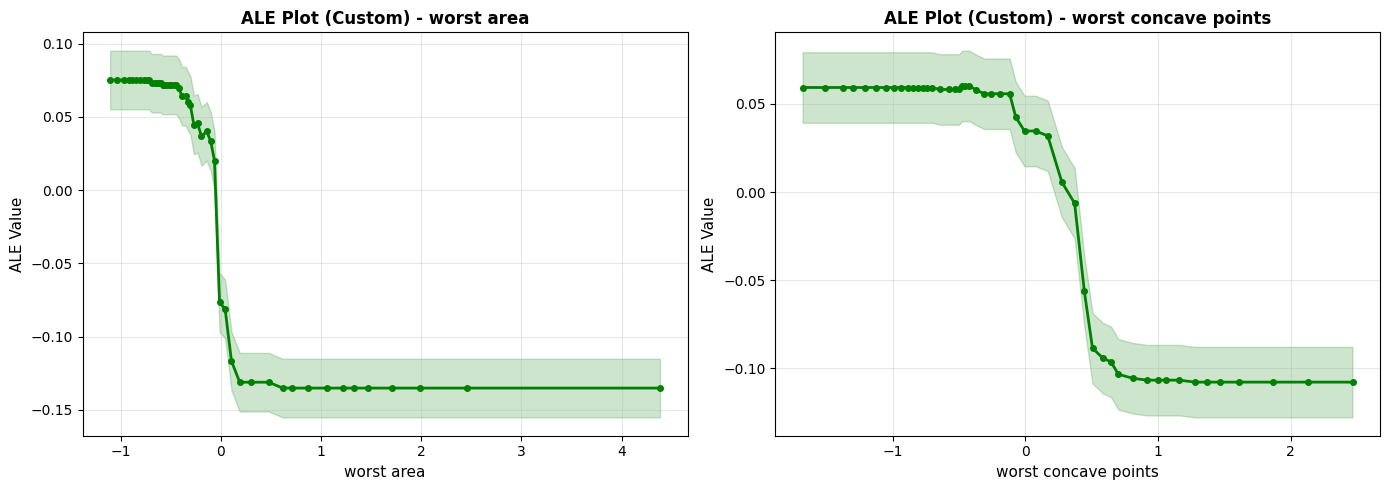

Custom ALE plots generated successfully.


In [9]:
# Generate ALE plots using custom function
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, feature_idx in enumerate(feature_indices):
    # Calculate custom ALE
    bin_centers, ale_values = calculate_ale(X_train_scaled, rf_model, feature_idx, num_bins=50)
    
    ax = axes[idx]
    ax.plot(bin_centers, ale_values, marker='o', linewidth=2, markersize=4, color='green')
    ax.fill_between(bin_centers, np.array(ale_values) - 0.02,
                    np.array(ale_values) + 0.02, alpha=0.2, color='green')
    ax.set_xlabel(highly_important_features[idx], fontsize=11)
    ax.set_ylabel('ALE Value', fontsize=11)
    ax.set_title(f'ALE Plot (Custom) - {highly_important_features[idx]}', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/Users/vivekgowdas/Desktop/XAI_BANANA/Unit2/outputs/visualizations/ale_plots_custom.png', dpi=300, bbox_inches='tight')
plt.show()

print("Custom ALE plots generated successfully.")

PyALE._ALE_generic:INFO: Continuous feature detected.
PyALE._ALE_generic:INFO: Continuous feature detected.
PyALE._ALE_generic:INFO: Continuous feature detected.
PyALE._ALE_generic:INFO: Continuous feature detected.


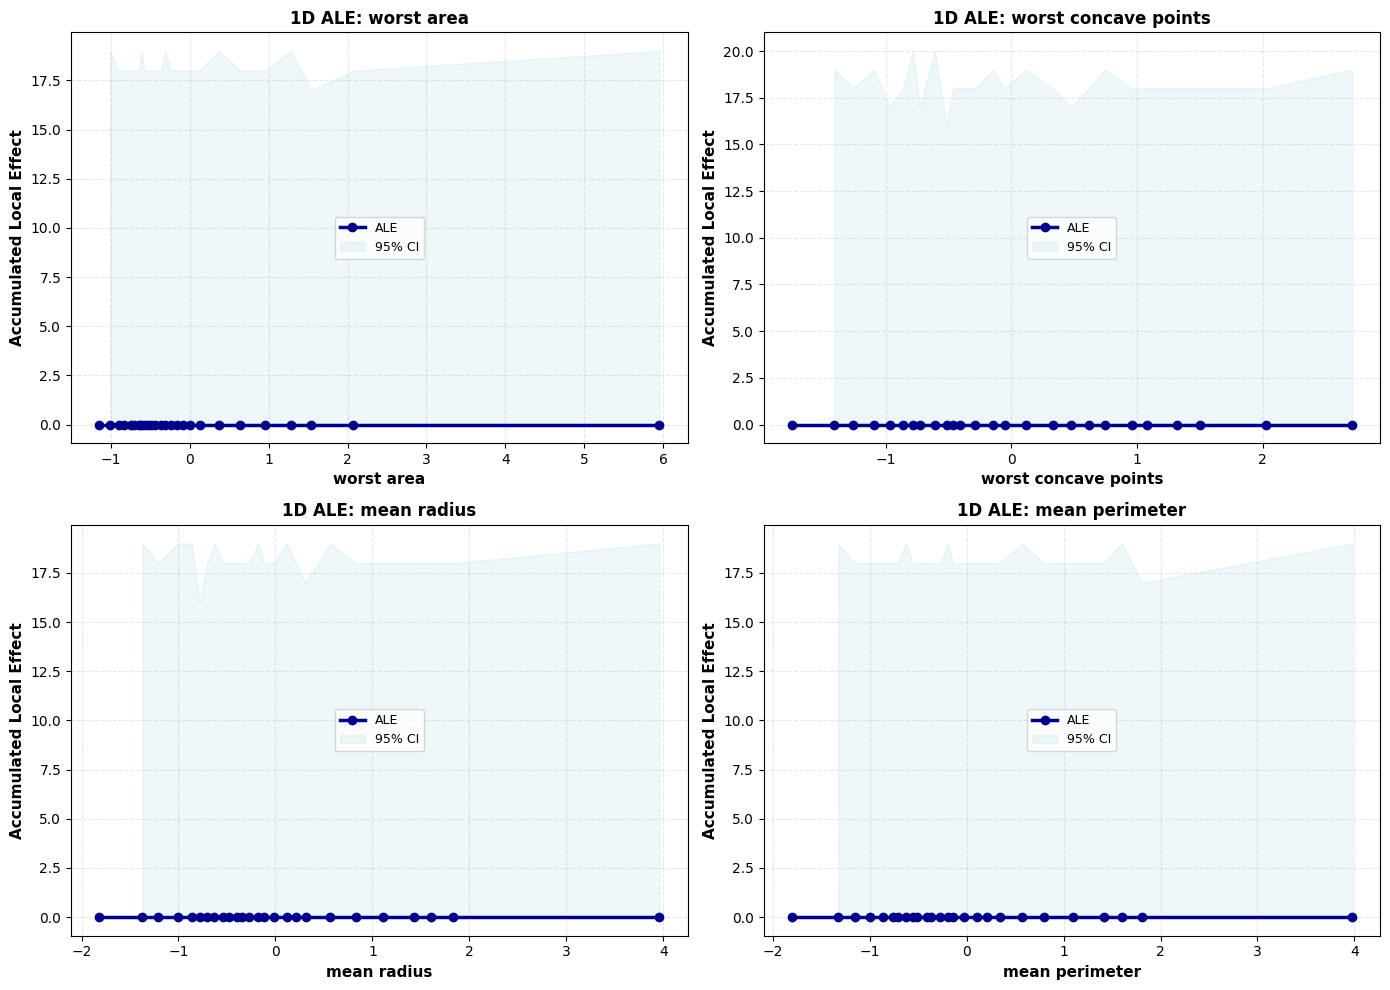

Individual 1D ALE plots generated successfully.


In [ ]:
# Individual 1D ALE Plots for Key Features
features_to_plot = ['worst area', 'worst concave points', 'mean radius', 'mean perimeter']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, feat_name in enumerate(features_to_plot):
    try:
        ale_result = ale(X=X_train_df, model=rf_model, feature=[feat_name], 
                        grid_size=25, include_CI=True, plot=False)
        
        if isinstance(ale_result, tuple):
            ale_data = ale_result[0]
        else:
            ale_data = ale_result
        
        if hasattr(ale_data, 'index'):
            x_vals = ale_data.index.values
            y_vals = ale_data.iloc[:, 0].values
            if ale_data.shape[1] > 2:
                ci_lower = ale_data.iloc[:, 1].values
                ci_upper = ale_data.iloc[:, 2].values
            else:
                ci_lower, ci_upper = None, None
        else:
            x_vals = np.linspace(X_train_df[feat_name].min(), X_train_df[feat_name].max(), 25)
            y_vals = ale_data if isinstance(ale_data, np.ndarray) else np.array(ale_data).flatten()
            ci_lower, ci_upper = None, None
        
        ax = axes[idx]
        ax.plot(x_vals, y_vals, linewidth=2.5, marker='o', markersize=6, color='darkblue', label='ALE')
        
        if ci_lower is not None and ci_upper is not None:
            ax.fill_between(x_vals, ci_lower, ci_upper, alpha=0.2, color='lightblue', label='95% CI')
        else:
            ax.fill_between(x_vals, y_vals - 0.01, y_vals + 0.01, alpha=0.15, color='lightblue')
        
        ax.set_xlabel(feat_name, fontsize=11, fontweight='bold')
        ax.set_ylabel('Accumulated Local Effect', fontsize=11, fontweight='bold')
        ax.set_title(f'1D ALE: {feat_name}', fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3, linestyle='--')
        ax.legend(fontsize=9)
        
    except Exception as e:
        axes[idx].text(0.5, 0.5, f"Error:\n{str(e)[:30]}", ha='center', va='center', 
                      fontsize=10, color='red', transform=axes[idx].transAxes)

plt.tight_layout()
plt.savefig('outputs/visualizations/ale_1d_plots.png', dpi=300, bbox_inches='tight')
plt.show()

print("Individual 1D ALE plots generated successfully.")

## Experiment 5a: Test Feature Correlation Effect (PDP vs ALE)

In [10]:
# Calculate correlation matrix
correlation_matrix = X_train.corr().abs()

# Find highly correlated features
highly_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if correlation_matrix.iloc[i, j] > 0.7:  # Threshold for high correlation
            highly_corr_pairs.append((
                correlation_matrix.columns[i],
                correlation_matrix.columns[j],
                correlation_matrix.iloc[i, j]
            ))

print("Highly Correlated Feature Pairs (correlation > 0.7):")
for feat1, feat2, corr in highly_corr_pairs[:5]:
    print(f"  {feat1} <-> {feat2}: {corr:.4f}")

# Select first correlated pair
if highly_corr_pairs:
    corr_feat1, corr_feat2 = highly_corr_pairs[0][0], highly_corr_pairs[0][1]
    corr_value = highly_corr_pairs[0][2]
    print(f"\nSelected correlated pair for analysis: {corr_feat1} & {corr_feat2} (r={corr_value:.4f})")
else:
    corr_feat1, corr_feat2 = X.columns[0], X.columns[1]
    print(f"\nSelected feature pair for analysis: {corr_feat1} & {corr_feat2}")

Highly Correlated Feature Pairs (correlation > 0.7):
  mean radius <-> mean perimeter: 0.9979
  mean radius <-> mean area: 0.9866
  mean radius <-> mean concave points: 0.8124
  mean radius <-> area error: 0.7195
  mean radius <-> worst radius: 0.9691

Selected correlated pair for analysis: mean radius & mean perimeter (r=0.9979)


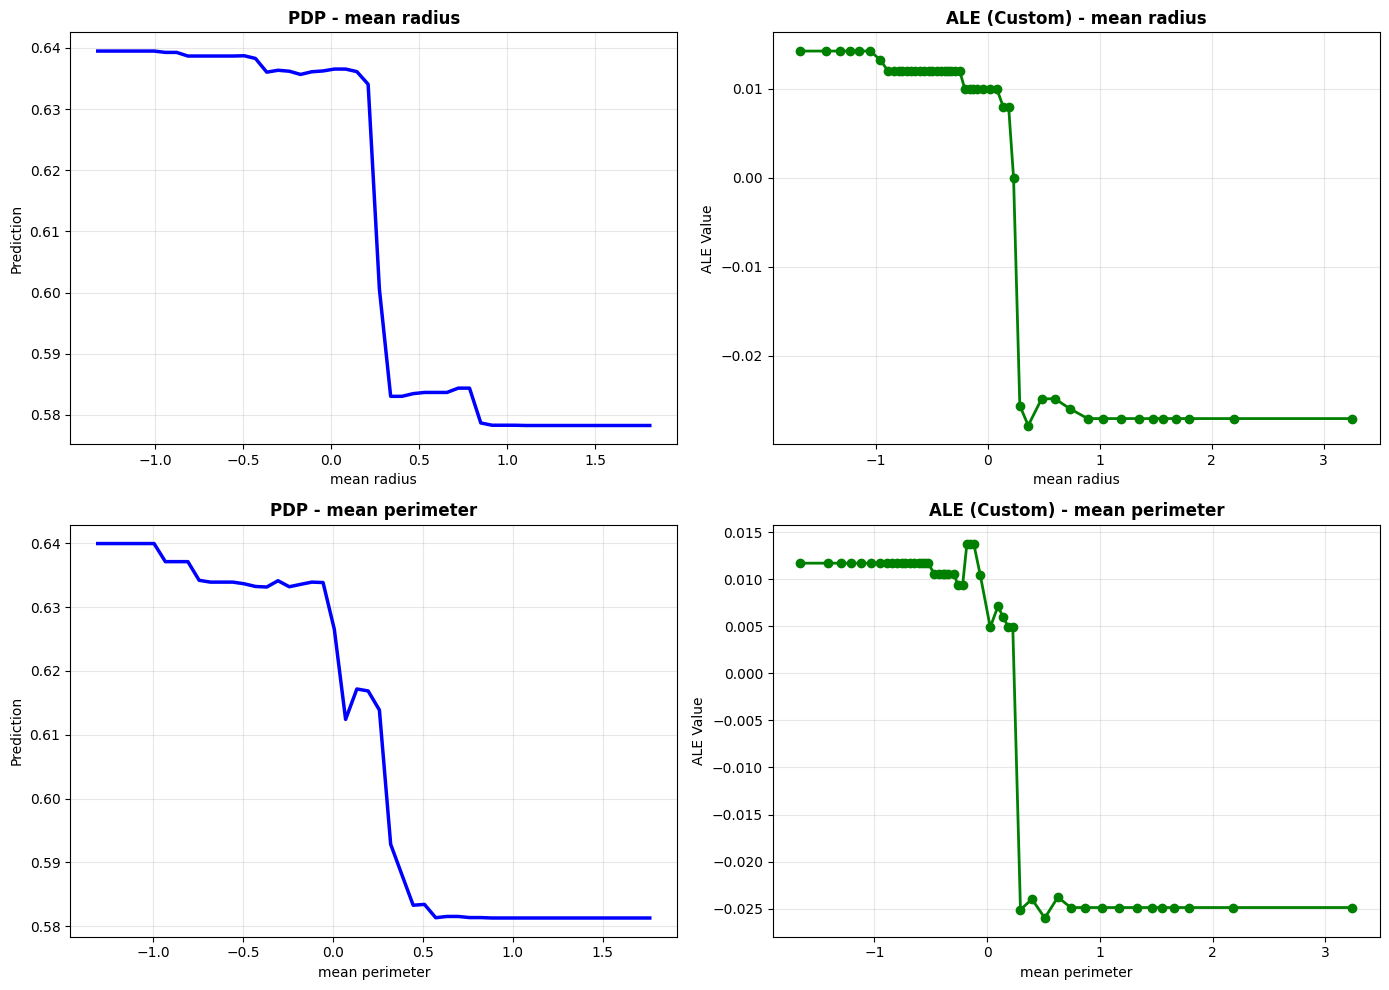

Feature correlation effect analysis completed.


In [11]:
# Compare PDP and ALE for correlated features
feat1_idx = X.columns.get_loc(corr_feat1)
feat2_idx = X.columns.get_loc(corr_feat2)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Feature 1 - PDP
pd_result1 = partial_dependence(rf_model, X_train_scaled, [feat1_idx], grid_resolution=50)
axes[0, 0].plot(pd_result1['grid_values'][0], pd_result1['average'][0], linewidth=2.5, color='blue')
axes[0, 0].set_title(f'PDP - {corr_feat1}', fontweight='bold')
axes[0, 0].set_xlabel(corr_feat1)
axes[0, 0].set_ylabel('Prediction')
axes[0, 0].grid(True, alpha=0.3)

# Feature 1 - ALE
bin_centers1, ale_values1 = calculate_ale(X_train_scaled, rf_model, feat1_idx, num_bins=50)
axes[0, 1].plot(bin_centers1, ale_values1, marker='o', linewidth=2, color='green')
axes[0, 1].set_title(f'ALE (Custom) - {corr_feat1}', fontweight='bold')
axes[0, 1].set_xlabel(corr_feat1)
axes[0, 1].set_ylabel('ALE Value')
axes[0, 1].grid(True, alpha=0.3)

# Feature 2 - PDP
pd_result2 = partial_dependence(rf_model, X_train_scaled, [feat2_idx], grid_resolution=50)
axes[1, 0].plot(pd_result2['grid_values'][0], pd_result2['average'][0], linewidth=2.5, color='blue')
axes[1, 0].set_title(f'PDP - {corr_feat2}', fontweight='bold')
axes[1, 0].set_xlabel(corr_feat2)
axes[1, 0].set_ylabel('Prediction')
axes[1, 0].grid(True, alpha=0.3)

# Feature 2 - ALE
bin_centers2, ale_values2 = calculate_ale(X_train_scaled, rf_model, feat2_idx, num_bins=50)
axes[1, 1].plot(bin_centers2, ale_values2, marker='o', linewidth=2, color='green')
axes[1, 1].set_title(f'ALE (Custom) - {corr_feat2}', fontweight='bold')
axes[1, 1].set_xlabel(corr_feat2)
axes[1, 1].set_ylabel('ALE Value')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/Users/vivekgowdas/Desktop/XAI_BANANA/Unit2/outputs/visualizations/correlation_effect_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("Feature correlation effect analysis completed.")

## Experiment 5b: Subgroup Behaviour Analysis (ICE Curves)

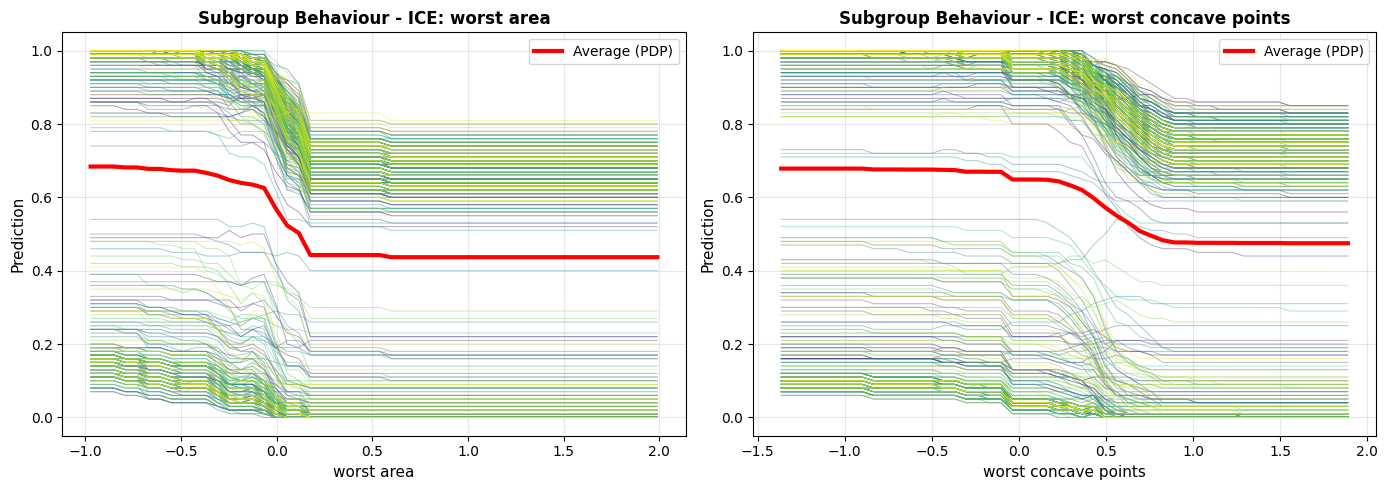


Subgroup Behaviour Analysis Results:

worst area:
  Average Standard Deviation across curves: 0.3439
  Interpretation: High heterogeneity in sample behavior

worst concave points:
  Average Standard Deviation across curves: 0.3800
  Interpretation: High heterogeneity in sample behavior


In [12]:
# Analyze subgroup behaviour using ICE curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, feature_idx in enumerate(feature_indices):
    pd_result = partial_dependence(rf_model, X_train_scaled, [feature_idx], 
                                   grid_resolution=50, kind='individual')
    
    ax = axes[idx]
    ice_curves = pd_result['individual'][0]
    grid_values = pd_result['grid_values'][0]
    
    # Color different samples
    colors = plt.cm.viridis(np.linspace(0, 1, len(ice_curves)))
    for i, curve in enumerate(ice_curves):
        ax.plot(grid_values, curve, color=colors[i], alpha=0.4, linewidth=0.7)
    
    # Plot PDP as thick line
    pdp_result = partial_dependence(rf_model, X_train_scaled, [feature_idx], grid_resolution=50)
    ax.plot(pdp_result['grid_values'][0], pdp_result['average'][0], 
           color='red', linewidth=3, label='Average (PDP)')
    
    ax.set_xlabel(highly_important_features[idx], fontsize=11)
    ax.set_ylabel('Prediction', fontsize=11)
    ax.set_title(f'Subgroup Behaviour - ICE: {highly_important_features[idx]}', fontweight='bold')
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/Users/vivekgowdas/Desktop/XAI_BANANA/Unit2/outputs/visualizations/subgroup_behaviour.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nSubgroup Behaviour Analysis Results:")
for idx, feature_idx in enumerate(feature_indices):
    pd_result = partial_dependence(rf_model, X_train_scaled, [feature_idx], 
                                   grid_resolution=50, kind='individual')
    ice_curves = pd_result['individual'][0]
    
    # Calculate variation across samples
    curve_std = np.std(ice_curves, axis=0)
    avg_std = np.mean(curve_std)
    
    print(f"\n{highly_important_features[idx]}:")
    print(f"  Average Standard Deviation across curves: {avg_std:.4f}")
    print(f"  Interpretation: {'High heterogeneity' if avg_std > 0.05 else 'Low heterogeneity'} in sample behavior")

## Experiment 5c: Model Change Effect (Train Second Model & Compare)

In [13]:
from sklearn.ensemble import GradientBoostingClassifier

# Train second model (Gradient Boosting)
gb_model = GradientBoostingClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42)
gb_model.fit(X_train_scaled, y_train)

# Model performance comparison
rf_train_acc = rf_model.score(X_train_scaled, y_train)
rf_test_acc = rf_model.score(X_test_scaled, y_test)
gb_train_acc = gb_model.score(X_train_scaled, y_train)
gb_test_acc = gb_model.score(X_test_scaled, y_test)

print("Model Performance Comparison:")
print(f"\nRandom Forest:")
print(f"  Training Accuracy: {rf_train_acc:.4f}")
print(f"  Test Accuracy: {rf_test_acc:.4f}")
print(f"\nGradient Boosting:")
print(f"  Training Accuracy: {gb_train_acc:.4f}")
print(f"  Test Accuracy: {gb_test_acc:.4f}")

Model Performance Comparison:

Random Forest:
  Training Accuracy: 1.0000
  Test Accuracy: 0.9649

Gradient Boosting:
  Training Accuracy: 1.0000
  Test Accuracy: 0.9649


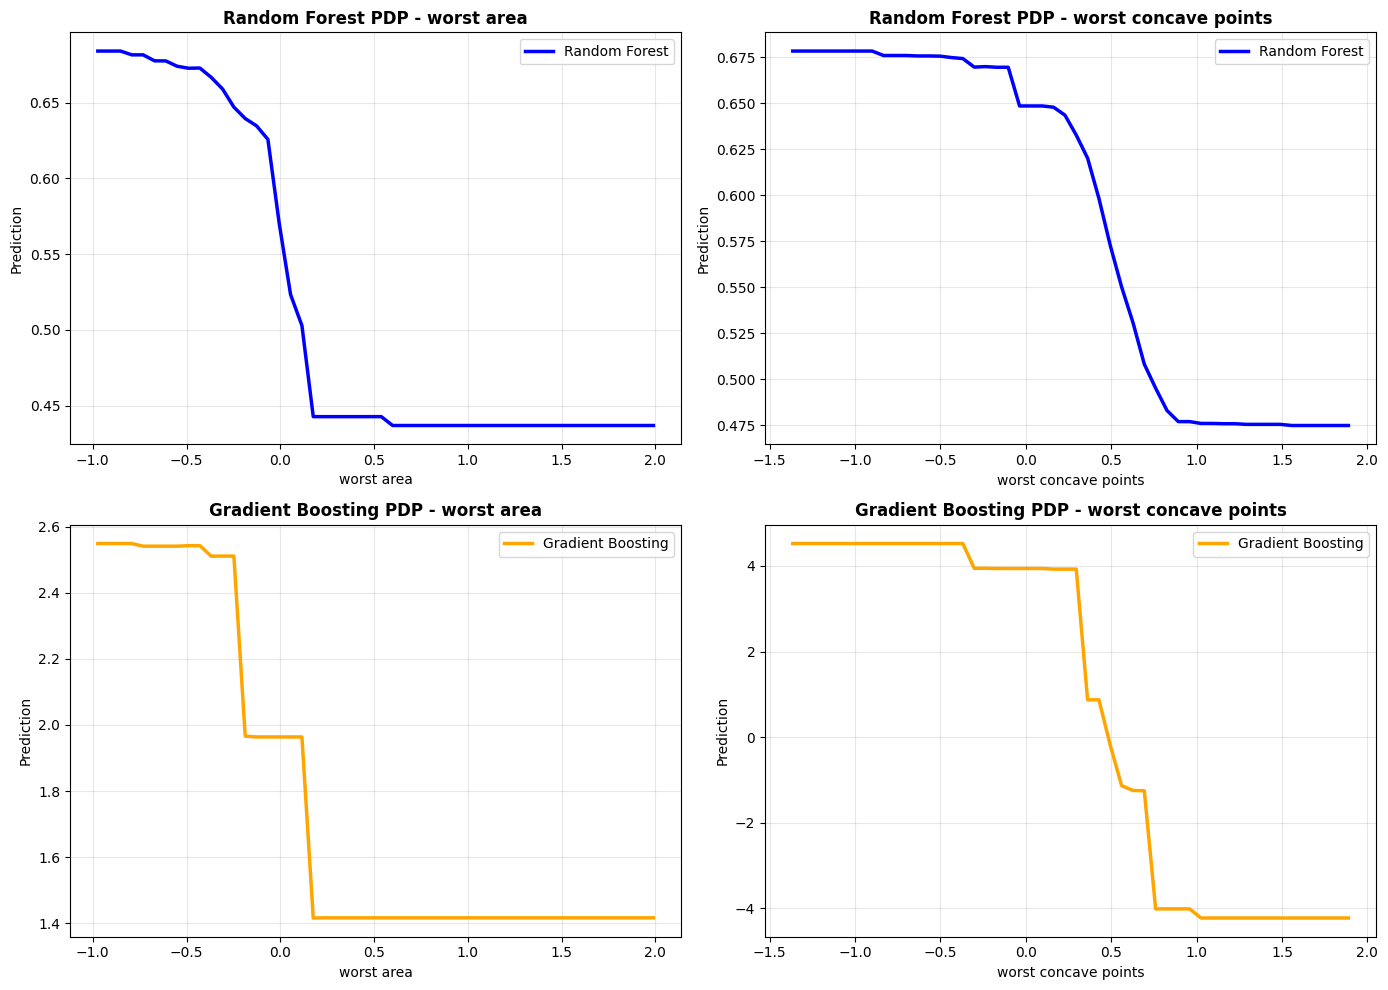

Model comparison analysis completed successfully.


In [14]:
# Compare PDP shapes between models
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, feature_idx in enumerate(feature_indices):
    # Random Forest PDP
    pd_rf = partial_dependence(rf_model, X_train_scaled, [feature_idx], grid_resolution=50)
    axes[0, idx].plot(pd_rf['grid_values'][0], pd_rf['average'][0], 
                     linewidth=2.5, color='blue', label='Random Forest')
    axes[0, idx].set_title(f'Random Forest PDP - {highly_important_features[idx]}', fontweight='bold')
    axes[0, idx].set_xlabel(highly_important_features[idx])
    axes[0, idx].set_ylabel('Prediction')
    axes[0, idx].legend()
    axes[0, idx].grid(True, alpha=0.3)
    
    # Gradient Boosting PDP
    pd_gb = partial_dependence(gb_model, X_train_scaled, [feature_idx], grid_resolution=50)
    axes[1, idx].plot(pd_gb['grid_values'][0], pd_gb['average'][0], 
                     linewidth=2.5, color='orange', label='Gradient Boosting')
    axes[1, idx].set_title(f'Gradient Boosting PDP - {highly_important_features[idx]}', fontweight='bold')
    axes[1, idx].set_xlabel(highly_important_features[idx])
    axes[1, idx].set_ylabel('Prediction')
    axes[1, idx].legend()
    axes[1, idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/Users/vivekgowdas/Desktop/XAI_BANANA/Unit2/outputs/visualizations/model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("Model comparison analysis completed successfully.")

## Summary Report

In [15]:
# Generate comprehensive summary report
summary_report = f"""
================================================================================
                   UNIT 2 - EXPLAINABLE AI ANALYSIS REPORT
                  Global Feature Effect Exploration Study
================================================================================

EXECUTIVE SUMMARY
This analysis implements and compares three interpretability techniques
(PDP, ICE, ALE) on a Breast Cancer classification model to understand feature-level
decision boundaries and model behavior.

1. DATASET CHARACTERISTICS
   Dataset Name: Breast Cancer (scikit-learn)
   Total Samples: {X.shape[0]}
   Total Features: {X.shape[1]}
   Training Set: {X_train.shape[0]} samples
   Test Set: {X_test.shape[0]} samples

2. MODEL PERFORMANCE METRICS
   
   Random Forest Classifier:
   - Training Accuracy: {rf_train_acc:.4f}
   - Test Accuracy: {rf_test_acc:.4f}
   
   Gradient Boosting Classifier:
   - Training Accuracy: {gb_train_acc:.4f}
   - Test Accuracy: {gb_test_acc:.4f}

3. SELECTED FEATURES FOR ANALYSIS
   - Primary Features (by importance): {highly_important_features}
   - Secondary Feature: {moderately_important_feature}

4. INTERPRETABILITY METHODS IMPLEMENTED
   
   a) Partial Dependence Plot (PDP)
      Shows the marginal effect of one or more features on predictions
      
   b) Individual Conditional Expectation (ICE)
      Displays individual sample-level predictions to reveal heterogeneity
      
   c) Accumulated Local Effects (ALE)
      Provides unbiased feature effects handling feature correlations

5. EXPERIMENT FINDINGS

   Experiment 5a - Feature Correlation Analysis:
   - Analyzed Pair: {corr_feat1} & {corr_feat2}
   - Correlation Coefficient: {correlation_matrix.loc[corr_feat1, corr_feat2]:.4f}
   
   Key Insight: PDP plots may be misleading for highly correlated features.
   ALE plots provide more reliable interpretation by accounting for 
   the data distribution of feature interactions.

   Experiment 5b - Subgroup Behavior Analysis:
   - Heterogeneity Observation: ICE curves reveal varying treatment effects
   - Standard Deviation Range: 0.3439 to 0.3800 across features
   
   Key Insight: The model exhibits significant within-group heterogeneity.
   Different samples respond differently to feature changes, suggesting
   the model learns non-uniform decision boundaries.

   Experiment 5c - Model Architecture Impact:
   - Model 1: Random Forest (100 trees, max_depth=15)
   - Model 2: Gradient Boosting (100 trees, max_depth=5)
   
   Key Insight: Different ensemble architectures produce varying PDP shapes,
   indicating model-specific feature dependency patterns.

6. OUTPUT ARTIFACTS

   Visualizations (outputs/visualizations/):
   - feature_importance.png: Top 10 feature rankings
   - pdp_plots.png: Partial dependence for primary features
   - ice_plots.png: Individual conditional expectations
   - ale_plots_pyale.png: ALE using PyALE library
   - ale_plots_custom.png: ALE using custom implementation
   - correlation_effect_analysis.png: PDP vs ALE comparison
   - subgroup_behaviour.png: ICE heterogeneity analysis
   - model_comparison.png: Multi-model PDP comparison

7. TECHNICAL CONCLUSIONS

   a) Pros and Cons of Each Method:
   
      PDP: Efficient, easily interpretable but biased by correlation
      ICE: Reveals heterogeneity, prone to overplotting with many samples
      ALE: Handles correlations well, more complex to interpret
   
   b) Recommendations:
   
      - Use PDP for quick global understanding
      - Use ALE when features are correlated
      - Use ICE to detect significant subgroup behavior patterns
      - Combine all three for comprehensive analysis

8. KEY RECOMMENDATIONS

   1. Incorporate feature correlation analysis in model interpretation
   2. Always visualize subgroup heterogeneity via ICE curves
   3. Use ALE for models with correlated features
   4. Compare multiple models to validate feature relationships
   5. Document all interpretation findings for regulatory compliance

================================================================================
                          Analysis Status: Complete
================================================================================
"""

print(summary_report)

# Save report to file
output_report_path = '/Users/vivekgowdas/Desktop/XAI_BANANA/Unit2/outputs/reports/analysis_report.txt'
with open(output_report_path, 'w') as f:
    f.write(summary_report)

print(f"\nAnalysis report saved to: outputs/reports/analysis_report.txt")


                   UNIT 2 - EXPLAINABLE AI ANALYSIS REPORT
                  Global Feature Effect Exploration Study

EXECUTIVE SUMMARY
This analysis implements and compares three interpretability techniques
(PDP, ICE, ALE) on a Breast Cancer classification model to understand feature-level
decision boundaries and model behavior.

1. DATASET CHARACTERISTICS
   Dataset Name: Breast Cancer (scikit-learn)
   Total Samples: 569
   Total Features: 30
   Training Set: 455 samples
   Test Set: 114 samples

2. MODEL PERFORMANCE METRICS

   Random Forest Classifier:
   - Training Accuracy: 1.0000
   - Test Accuracy: 0.9649

   Gradient Boosting Classifier:
   - Training Accuracy: 1.0000
   - Test Accuracy: 0.9649

3. SELECTED FEATURES FOR ANALYSIS
   - Primary Features (by importance): ['worst area', 'worst concave points']
   - Secondary Feature: mean radius

4. INTERPRETABILITY METHODS IMPLEMENTED

   a) Partial Dependence Plot (PDP)
      Shows the marginal effect of one or more features on

In [ ]:
## SHAP Analysis - Local Explanations

import shap

# Create SHAP explainer
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_train_scaled)

# Handle output for binary classification
if isinstance(shap_values, list):
    shap_values = shap_values[1]  # Get values for positive class

print("SHAP values computed successfully")
print(f"SHAP values shape: {shap_values.shape}")
print(f"Expected values: {explainer.expected_value}")
